# number_of_offers prediciton


It will:

1. Load the saved 2024 test vectors.
2. Reload the saved Linear Regression, Decision Tree, Random Forest, GBT, and preprocessing pipeline.
3. Reload the saved 2023 validation metrics and preserve the validation-selected final model.
4. Evaluate all four models on the held-out 2024 test set.
5. Reconstruct **actual feature/category names** from the fitted preprocessing pipeline.
6. Produce model-performance, prediction, residual, and feature-importance/coefficient visuals with readable feature names.


## 1. Imports

In [1]:
# Purpose: Import the PySpark DataFrame, ML, evaluation, plotting, and utility components used in this stage.
from pyspark.sql import functions as F
from pyspark import StorageLevel
from pyspark.ml import PipelineModel
from pyspark.ml.regression import (LinearRegressionModel, DecisionTreeRegressionModel,
    RandomForestRegressionModel, GBTRegressionModel)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 2. Paths from the training notebook

In [2]:
# Purpose: Define the GCS input, output, vector, and model locations used by this stage.
RAW_ML_PATH = ("gs://federal-contracts/" "silver/contracts_ml/v1/04_ml_ready/parquet")
VECTOR_ROOT = ("gs://federal-contracts/" "gold/ml_vectors/offers_col/v1")
TEST_VECTOR_PATH = f"{VECTOR_ROOT}/test"
# The original notebook used two model roots at different points.
# These candidates cover the paths that were actually used/saved there.
MODEL_PATH_CANDIDATES = {"Linear Regression": (LinearRegressionModel,
        [
            "gs://federal-contracts/models/contracts_ml/v1/offers/linear_regression",
            "gs://federal-contracts/models/offers/linear_regression",
        ],
    ),
    "Decision Tree": (
        DecisionTreeRegressionModel,
        [
            "gs://federal-contracts/models/offers/decision_tree",
            "gs://federal-contracts/models/contracts_ml/v1/offers/decision_tree",
        ],
    ),
    "Random Forest": (
        RandomForestRegressionModel,
        [
            "gs://federal-contracts/models/offers/random_forest",
            "gs://federal-contracts/models/contracts_ml/v1/offers/random_forest",
        ],
    ),
    "GBT": (
        GBTRegressionModel,
        [
            "gs://federal-contracts/models/offers/gbt",
            "gs://federal-contracts/models/contracts_ml/v1/offers/gbt",
        ],
    ),
}
PREPROCESSOR_CANDIDATES = [
    "gs://federal-contracts/models/offers/preprocessor",
    "gs://federal-contracts/models/contracts_ml/v1/offers/preprocessor",
]
VALIDATION_RESULTS_CANDIDATES = [
    "gs://federal-contracts/models/offers/validation_metrics",
    "gs://federal-contracts/models/contracts_ml/v1/offers/validation_metrics",
]

## 3. Small helpers for resolving saved GCS paths

In [3]:
# Purpose: Define helper functions to resolve existing GCS paths and load the first available saved Spark model.
def path_exists(path):
    jpath = spark._jvm.org.apache.hadoop.fs.Path(path)
    fs = jpath.getFileSystem(spark._jsc.hadoopConfiguration())
    return bool(fs.exists(jpath))
def first_existing_path(candidates):
    for path in candidates:
        if path_exists(path):
            return path
    raise FileNotFoundError("None of these saved paths exists:\n" + "\n".join(candidates))
def load_first_model(model_class, candidates):
    path = first_existing_path(candidates)
    model = model_class.load(path)
    print(f"Loaded {model_class.__name__}:", path)
    return model, path

## 4. Load and cache the 2024 test vectors

In [4]:
# Purpose: Load the required Parquet data into `offers_test_f` for this Big Data processing stage.
offers_test_f = (spark.read.parquet(TEST_VECTOR_PATH).select("id", "award_id", "piid", "source_year", "split",
        "offers_label",
        "label",
        "features"
    )
    .cache()
)
test_count = offers_test_f.count()
print(
    "2024 test rows:",
    f"{test_count:,}"
)
offers_test_f.printSchema()

2024 test rows: 1,656,042
root
 |-- id: string (nullable = true)
 |-- award_id: string (nullable = true)
 |-- piid: string (nullable = true)
 |-- source_year: integer (nullable = true)
 |-- split: string (nullable = true)
 |-- offers_label: double (nullable = true)
 |-- label: double (nullable = true)
 |-- features: vector (nullable = true)



## 5. Reload all trained models and the fitted preprocessing pipeline

In [5]:
# Purpose: Load the available trained offer models and record the model paths used for evaluation.
trained_models = {}
loaded_model_paths = {}
for model_name, (model_class, path_candidates) in MODEL_PATH_CANDIDATES.items():
    model, loaded_path = load_first_model(model_class, path_candidates)
    trained_models[model_name] = model
    loaded_model_paths[model_name] = loaded_path
preprocessor_path = first_existing_path(PREPROCESSOR_CANDIDATES)
offers_feature_model = PipelineModel.load(
    preprocessor_path
)
print(
    "Loaded preprocessing PipelineModel:",
    preprocessor_path
)

Loaded LinearRegressionModel: gs://federal-contracts/models/contracts_ml/v1/offers/linear_regression


Loaded DecisionTreeRegressionModel: gs://federal-contracts/models/offers/decision_tree


Loaded RandomForestRegressionModel: gs://federal-contracts/models/offers/random_forest


Loaded GBTRegressionModel: gs://federal-contracts/models/offers/gbt


Loaded preprocessing PipelineModel: gs://federal-contracts/models/offers/preprocessor


## 6. Verify that every model matches the saved test feature vector

In [6]:
# Purpose: Load the available trained offer models and record the model paths used for evaluation.
sample_feature = (offers_test_f.select("features").filter(F.col("features").isNotNull()).first())
if sample_feature is None:
    raise ValueError("The test DataFrame contains no non-null feature vectors."
    )
test_feature_count = (
    sample_feature["features"].size
)
print(
    "Test feature vector size:",
    test_feature_count
)
for model_name, model in trained_models.items():
    print(
        model_name,
        "expects",
        model.numFeatures,
        "features"
    )
    assert (
        model.numFeatures
        ==
        test_feature_count
    ), (
        f"Feature mismatch for {model_name}: "
        f"model={model.numFeatures}, "
        f"test={test_feature_count}"
    )
print(
    "All model feature dimensions match."
)

Test feature vector size: 1480
Linear Regression expects 1480 features
Decision Tree expects 1480 features
Random Forest expects 1480 features
GBT expects 1480 features
All model feature dimensions match.


## 7. Reload 2023 validation results and preserve the validation-selected final model

The 2024 test set must not be used to choose the winning model.

In [7]:
# Purpose: Load the required Parquet data into `validation_results_path` for this Big Data processing stage.
validation_results_path = first_existing_path(VALIDATION_RESULTS_CANDIDATES)
validation_results = (spark.read.parquet(validation_results_path))
print("Loaded validation metrics:",
    validation_results_path
)
validation_results.orderBy(
    F.asc("mae")
).show(
    truncate=False
)
best_validation_row = (
    validation_results
    .orderBy(
        F.asc("mae")
    )
    .first()
)
best_model_name = (
    best_validation_row["model"]
)
assert (
    best_model_name
    in trained_models
), (
    f"Validation-selected model "
    f"{best_model_name!r} "
    f"was not loaded."
)
best_model = (
    trained_models[
        best_model_name
    ]
)
print(
    "FINAL MODEL SELECTED FROM 2023 VALIDATION:",
    best_model_name
)
print(
    "Validation MAE:",
    float(
        best_validation_row["mae"]
    )
)

Loaded validation metrics: gs://federal-contracts/models/offers/validation_metrics


+-----------------+------------------+------------------+-------------------+------------------+
|model            |rmse              |mae               |r2                 |log_rmse          |
+-----------------+------------------+------------------+-------------------+------------------+
|Decision Tree    |63.89288517400981 |10.648421645323635|0.9275600790901117 |0.5728833540381271|
|GBT              |81.07294504829257 |15.755881626879507|0.8833660814537481 |0.598736534805922 |
|Linear Regression|207.20176333002658|57.31755562168811 |0.23816685769001578|1.020691564718085 |
|Random Forest    |229.1034154247844 |60.77929790648331 |0.06860029686565983|1.0061112786892552|
+-----------------+------------------+------------------+-------------------+------------------+



FINAL MODEL SELECTED FROM 2023 VALIDATION: Decision Tree
Validation MAE: 10.648421645323635


## 8. Prediction and evaluation helpers

In [8]:
# Purpose: Define the helper functions used together in this Big Data processing step.
def add_original_prediction(predictions):
    return (predictions.withColumn("prediction_original", F.greatest(F.exp(F.col("prediction")) - F.lit(1.0),
                F.lit(0.0)
            )
        )
    )
def evaluate_predictions_once(predictions):
    # One Spark aggregation gives all test metrics and tolerance counts.
    evaluated = (
        predictions
        .withColumn(
            "_error",
            F.col("prediction_original")
            - F.col("offers_label")
        )
        .withColumn(
            "_abs_error",
            F.abs(
                F.col("_error")
            )
        )
        .withColumn(
            "_sq_error",
            F.pow(
                F.col("_error"),
                2
            )
        )
        .withColumn(
            "_log_sq_error",
            F.pow(
                F.col("prediction")
                - F.col("label"),
                2
            )
        )
    )
    row = (
        evaluated
        .agg(
            F.count("*").alias("n"),
            F.sum(
                "_abs_error"
            ).alias("sum_abs_error"),
            F.sum(
                "_sq_error"
            ).alias("sum_sq_error"),
            F.sum(
                "_log_sq_error"
            ).alias("sum_log_sq_error"),
            F.sum(
                "offers_label"
            ).alias("sum_y"),
            F.sum(
                F.pow(
                    F.col("offers_label"),
                    2
                )
            ).alias("sum_y2"),
            F.sum(
                F.when(
                    F.round(
                        F.col("prediction_original")
                    )
                    ==
                    F.col("offers_label"),
                    1
                ).otherwise(0)
            ).alias("exact_rounded"),
            F.sum(
                F.when(
                    F.col("_abs_error") <= 1,
                    1
                ).otherwise(0)
            ).alias("within_1"),
            F.sum(
                F.when(
                    F.col("_abs_error") <= 2,
                    1
                ).otherwise(0)
            ).alias("within_2"),
            F.sum(
                F.when(
                    F.col("_abs_error") <= 5,
                    1
                ).otherwise(0)
            ).alias("within_5")
        )
        .first()
    )
    n = int(row["n"])
    if n == 0:
        raise ValueError(
            "No predictions were available for evaluation."
        )
    sse = float(
        row["sum_sq_error"]
    )
    sum_y = float(
        row["sum_y"]
    )
    sum_y2 = float(
        row["sum_y2"]
    )
    sst = (
        sum_y2
        -
        (sum_y ** 2) / n
    )
    mae = (
        float(
            row["sum_abs_error"]
        )
        / n
    )
    rmse = (
        sse / n
    ) ** 0.5
    r2 = (
        1.0 - sse / sst
        if sst > 0
        else float("nan")
    )
    log_rmse = (
        float(
            row["sum_log_sq_error"]
        )
        / n
    ) ** 0.5
    exact = int(
        row["exact_rounded"]
    )
    within_1 = int(
        row["within_1"]
    )
    within_2 = int(
        row["within_2"]
    )
    within_5 = int(
        row["within_5"]
    )
    return {
        "total_predictions": n,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        "Log_RMSE": log_rmse,
        "exact_correct": exact,
        "exact_accuracy_pct": (
            exact / n * 100
        ),
        "within_1_pct": (
            within_1 / n * 100
        ),
        "within_2_pct": (
            within_2 / n * 100
        ),
        "within_5_pct": (
            within_5 / n * 100
        ),
    }

## 9. Evaluate all four models on the held-out 2024 test set

In [9]:
# Purpose: Generate model predictions for evaluation on the selected data split.
test_metrics_by_model = {}
for model_name, model in trained_models.items():
    print("\nTesting:", model_name)
    predictions = (add_original_prediction(model.transform(offers_test_f))
    )
    metrics = (
        evaluate_predictions_once(
            predictions
        )
    )
    test_metrics_by_model[
        model_name
    ] = metrics
    print(
        "MAE:",
        round(
            metrics["MAE"],
            4
        )
    )
    print(
        "RMSE:",
        round(
            metrics["RMSE"],
            4
        )
    )
    print(
        "R2:",
        round(
            metrics["R2"],
            4
        )
    )
    print(
        "Log_RMSE:",
        round(
            metrics["Log_RMSE"],
            4
        )
    )


Testing: Linear Regression


MAE: 58.1634
RMSE: 206.3918
R2: 0.2693
Log_RMSE: 1.0281

Testing: Decision Tree


MAE: 10.6024
RMSE: 62.1229
R2: 0.9338
Log_RMSE: 0.5949

Testing: Random Forest


MAE: 62.6744
RMSE: 231.6313
R2: 0.0796
Log_RMSE: 1.0054

Testing: GBT


MAE: 15.0215
RMSE: 75.1334
R2: 0.9032
Log_RMSE: 0.6087


In [10]:
# Purpose: Evaluate regression performance using the configured error and goodness-of-fit metrics.
test_results_pd = pd.DataFrame([{"model": model_name, "rmse": metrics["RMSE"], "mae": metrics["MAE"],
            "r2": metrics["R2"], "log_rmse": metrics["Log_RMSE"], "total_predictions": metrics[
                "total_predictions"],
            "exact_accuracy_pct": metrics[
                "exact_accuracy_pct"
            ],
            "within_1_pct": metrics[
                "within_1_pct"
            ],
            "within_2_pct": metrics[
                "within_2_pct"
            ],
            "within_5_pct": metrics[
                "within_5_pct"
            ],
        }
        for model_name, metrics
        in test_metrics_by_model.items()
    ]
).sort_values(
    "mae"
).reset_index(
    drop=True
)
test_results_pd

,model,rmse,mae,r2,log_rmse,total_predictions,exact_accuracy_pct,within_1_pct,within_2_pct,within_5_pct
0,Decision Tree,62.122936,10.602442,0.933798,0.594862,1656042,37.554905,47.619022,67.730589,84.666452
1,GBT,75.133403,15.021461,0.903165,0.608673,1656042,26.993820,40.384906,62.471302,81.676914
2,Linear Regression,206.391764,58.163361,0.269276,1.028121,1656042,17.109107,30.192833,44.545126,62.863261
3,Random Forest,231.631322,62.674436,0.079629,1.005402,1656042,7.439123,19.136109,51.445797,78.944677


## 10. Final 2024 test result for the model selected on 2023 validation

This is the result that should be reported as the **final held-out test result**.

In [11]:
# Purpose: Evaluate regression performance using the configured error and goodness-of-fit metrics.
final_test_metrics = (test_metrics_by_model[best_model_name])
print("FINAL 2024 TEST RESULTS")
print("Validation-selected model:", best_model_name
)
for metric in [
    "MAE",
    "RMSE",
    "R2",
    "Log_RMSE"
]:
    print(
        metric,
        ":",
        round(
            final_test_metrics[
                metric
            ],
            4
        )
    )

FINAL 2024 TEST RESULTS
Validation-selected model: Decision Tree
MAE : 10.6024
RMSE : 62.1229
R2 : 0.9338
Log_RMSE : 0.5949


## 11. Model-comparison visuals — 2024 test

In [12]:
# Purpose: Define `plot_metric_bar` to encapsulate the `plot_metric_bar` processing logic for reuse.
def plot_metric_bar(dataframe, metric, ylabel, title, decimals=3):
    plot_df = (dataframe.sort_values(
            metric,
            ascending=(
                metric != "r2"
            )
        )
    )
    plt.figure(
        figsize=(10, 6)
    )
    bars = plt.bar(
        plot_df["model"],
        plot_df[metric]
    )
    plt.xlabel(
        "Model"
    )
    plt.ylabel(
        ylabel
    )
    plt.title(
        title
    )
    plt.xticks(
        rotation=20
    )
    plt.grid(
        axis="y",
        alpha=0.3
    )
    for bar, value in zip(
        bars,
        plot_df[metric]
    ):
        plt.text(
            bar.get_x()
            +
            bar.get_width() / 2,
            bar.get_height(),
            f"{value:.{decimals}f}",
            ha="center",
            va="bottom"
        )
    plt.tight_layout()
    plt.show()

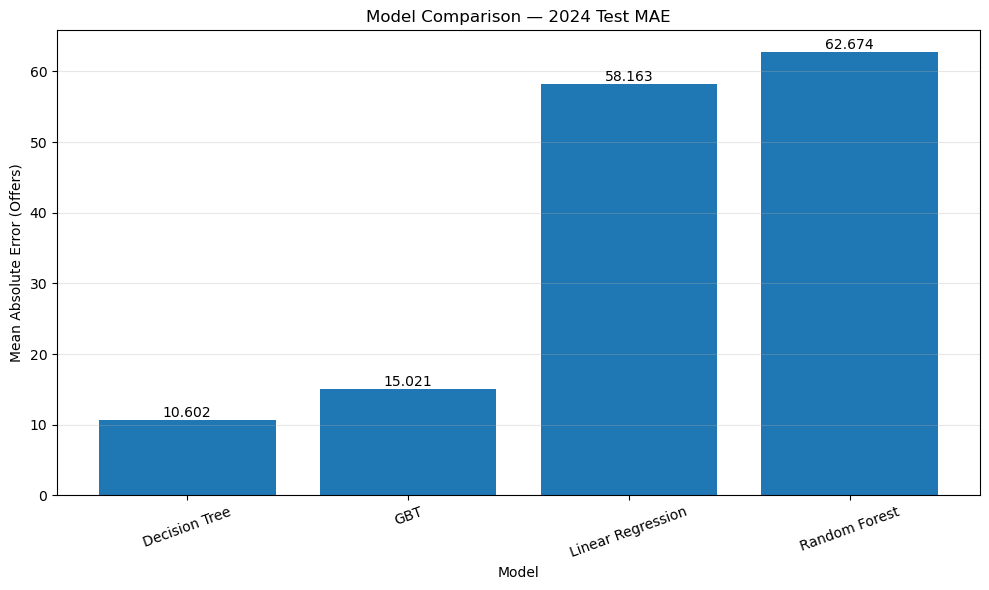

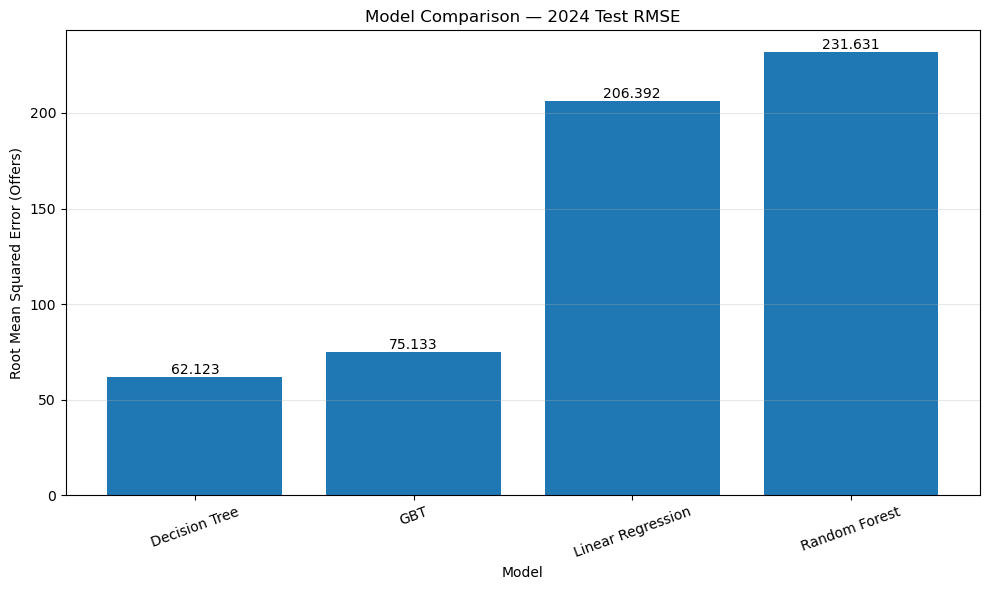

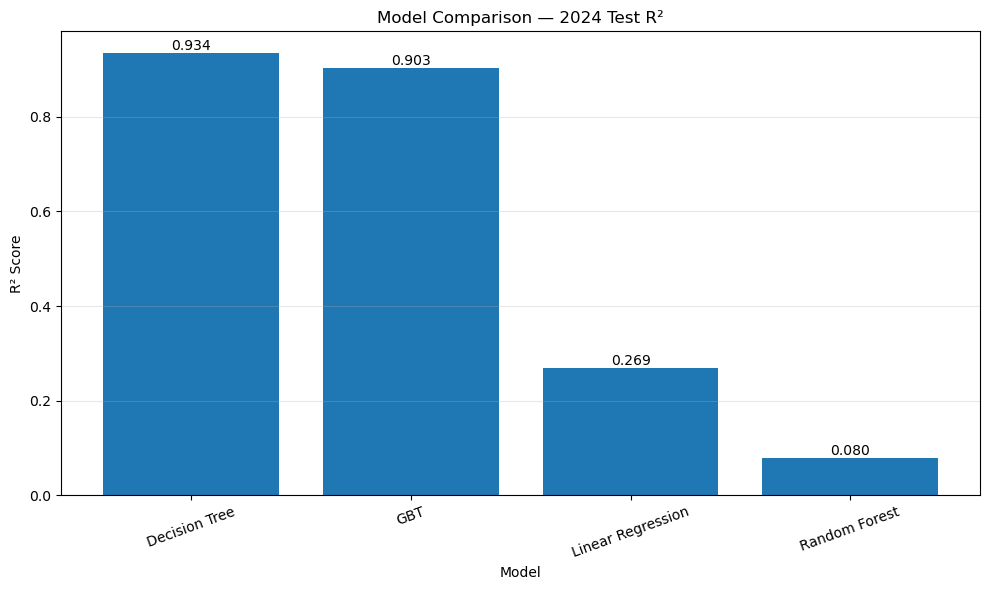

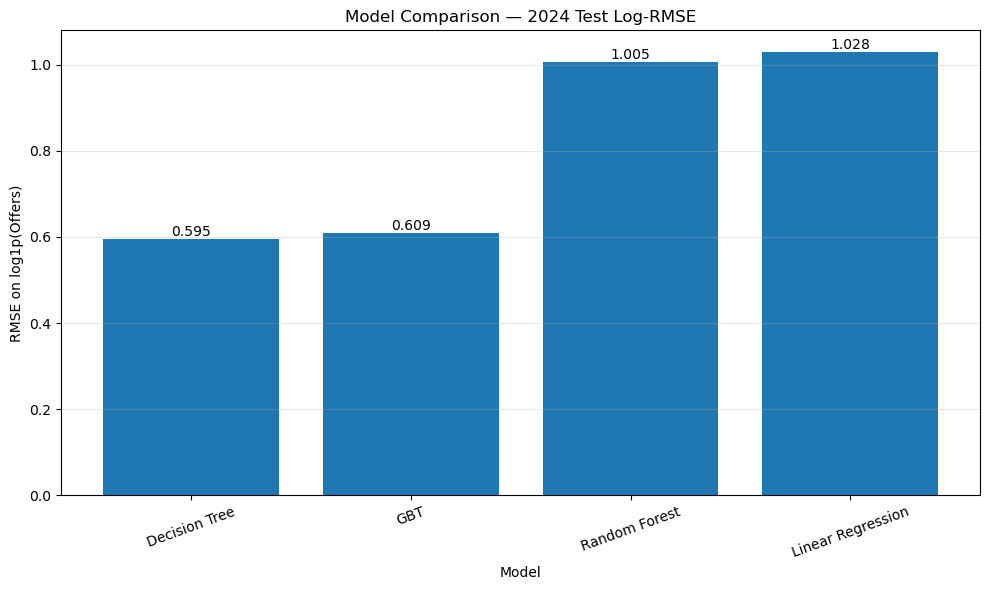

In [13]:
# Purpose: Evaluate regression performance using the configured error and goodness-of-fit metrics.
plot_metric_bar(test_results_pd, "mae", "Mean Absolute Error (Offers)", "Model Comparison — 2024 Test MAE")
plot_metric_bar(test_results_pd, "rmse", "Root Mean Squared Error (Offers)",
    "Model Comparison — 2024 Test RMSE"
)
plot_metric_bar(
    test_results_pd,
    "r2",
    "R² Score",
    "Model Comparison — 2024 Test R²"
)
plot_metric_bar(
    test_results_pd,
    "log_rmse",
    "RMSE on log1p(Offers)",
    "Model Comparison — 2024 Test Log-RMSE"
)

## 12. Prediction tolerance visual — 2024 test

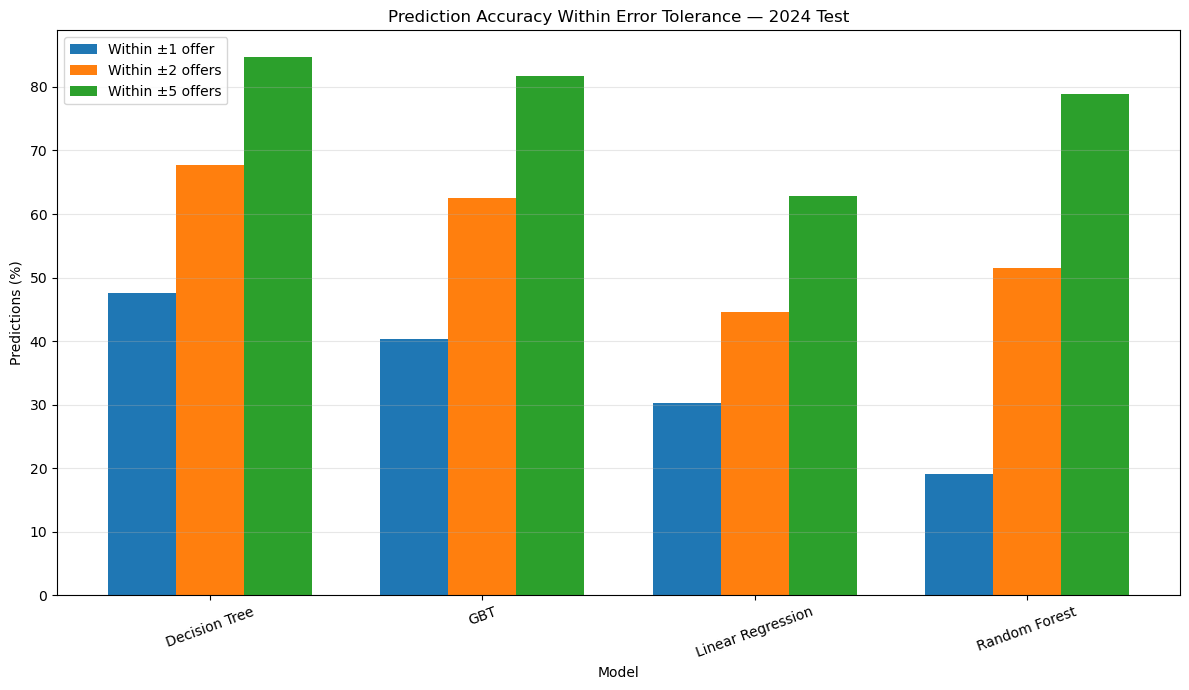

In [14]:
# Purpose: Visualize the computed Big Data statistics or model results for interpretation.
models = (test_results_pd["model"].tolist())
x = np.arange(len(models))
width = 0.25
plt.figure(figsize=(12, 7))
plt.bar(x - width,
    test_results_pd["within_1_pct"],
    width,
    label="Within ±1 offer"
)
plt.bar(
    x,
    test_results_pd["within_2_pct"],
    width,
    label="Within ±2 offers"
)
plt.bar(
    x + width,
    test_results_pd["within_5_pct"],
    width,
    label="Within ±5 offers"
)
plt.xticks(
    x,
    models,
    rotation=20
)
plt.ylabel(
    "Predictions (%)"
)
plt.xlabel(
    "Model"
)
plt.title(
    "Prediction Accuracy Within Error Tolerance — 2024 Test"
)
plt.legend()
plt.grid(
    axis="y",
    alpha=0.3
)
plt.tight_layout()
plt.show()

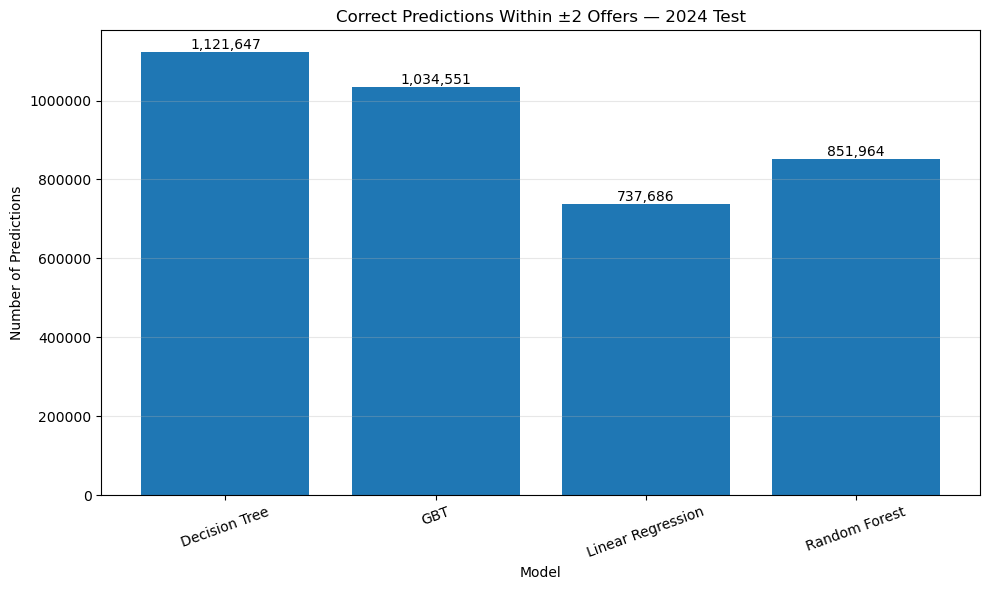

In [15]:
# Purpose: Visualize the computed Big Data statistics or model results for interpretation.
correct_count_pd = (test_results_pd[["model", "total_predictions", "within_2_pct"]].copy()
)
correct_count_pd[
    "correct_within_2"
] = (
    correct_count_pd[
        "within_2_pct"
    ]
    / 100.0
    *
    correct_count_pd[
        "total_predictions"
    ]
).round().astype(
    "int64"
)
plt.figure(
    figsize=(10, 6)
)
bars = plt.bar(
    correct_count_pd["model"],
    correct_count_pd["correct_within_2"]
)
plt.title(
    "Correct Predictions Within ±2 Offers — 2024 Test"
)
plt.xlabel(
    "Model"
)
plt.ylabel(
    "Number of Predictions"
)
plt.xticks(
    rotation=20
)
plt.ticklabel_format(
    style="plain",
    axis="y"
)
plt.grid(
    axis="y",
    alpha=0.3
)
for bar, value in zip(
    bars,
    correct_count_pd["correct_within_2"]
):
    plt.text(
        bar.get_x()
        +
        bar.get_width() / 2,
        bar.get_height(),
        f"{int(value):,}",
        ha="center",
        va="bottom"
    )
plt.tight_layout()
plt.show()

## 13. Final-model predictions for diagnostic visuals

In [16]:
# Purpose: Materialize the Spark DataFrame and verify the number of available records.
final_test_predictions = (add_original_prediction(best_model.transform(offers_test_f)).persist(
        StorageLevel.MEMORY_AND_DISK))
final_prediction_count = (
    final_test_predictions
    .count()
)
print(
    "Materialized final test predictions:",
    f"{final_prediction_count:,}"
)

Materialized final test predictions: 1,656,042


In [17]:
# Purpose: Display the resulting Spark rows or summary table for validation and interpretation.
(final_test_predictions.select("award_id", F.col("offers_label").alias("actual_offers"),
        F.round(
            "prediction_original",
            2
        ).alias(
            "predicted_offers"
        ),
        F.round(
            F.abs(
                F.col("offers_label")
                -
                F.col("prediction_original")
            ),
            2
        ).alias(
            "absolute_error"
        )
    )
    .show(
        50,
        truncate=False
    )
)

+---------------------------------------------------+-------------+----------------+--------------+
|award_id                                           |actual_offers|predicted_offers|absolute_error|
+---------------------------------------------------+-------------+----------------+--------------+
|CONT_AWD_47QSSC24F3R0L_4732_47QSHA21A000D_4732     |22.0         |22.04           |0.04          |
|CONT_AWD_47QSSC24F3T25_4732_47QSHA21A000D_4732     |22.0         |22.04           |0.04          |
|CONT_AWD_FA861222FB002_9700_FA861220D0016_9700     |28.0         |3.08            |24.92         |
|CONT_AWD_75N92022F00061_7529_75N92021A00007_7529   |1.0          |2.32            |1.32          |
|CONT_AWD_47QSSC24F3EQT_4732_47QSHA21A000D_4732     |22.0         |22.04           |0.04          |
|CONT_AWD_47QSSC24F3HZK_4732_47QSHA21A0008_4732     |22.0         |22.04           |0.04          |
|CONT_AWD_47QSSC24F3KL7_4732_47QSHA21A000D_4732     |22.0         |22.04           |0.04          |


## 14. Actual vs predicted — validation-selected model on 2024 test

In [18]:
# Purpose: Filter the Spark records to the valid subset required for the next analysis or modeling step.
scatter_pd = (final_test_predictions.select(F.col("offers_label").alias("actual"), F.col("prediction_original"
        ).alias("predicted"))
    .filter(
        F.col("actual").isNotNull()
        &
        F.col("predicted").isNotNull()
    )
    .sample(
        False,
        0.02,
        seed=42
    )
    .limit(10000)
    .toPandas()
)
print(
    "Scatter sample rows:",
    len(scatter_pd)
)

Scatter sample rows: 10000


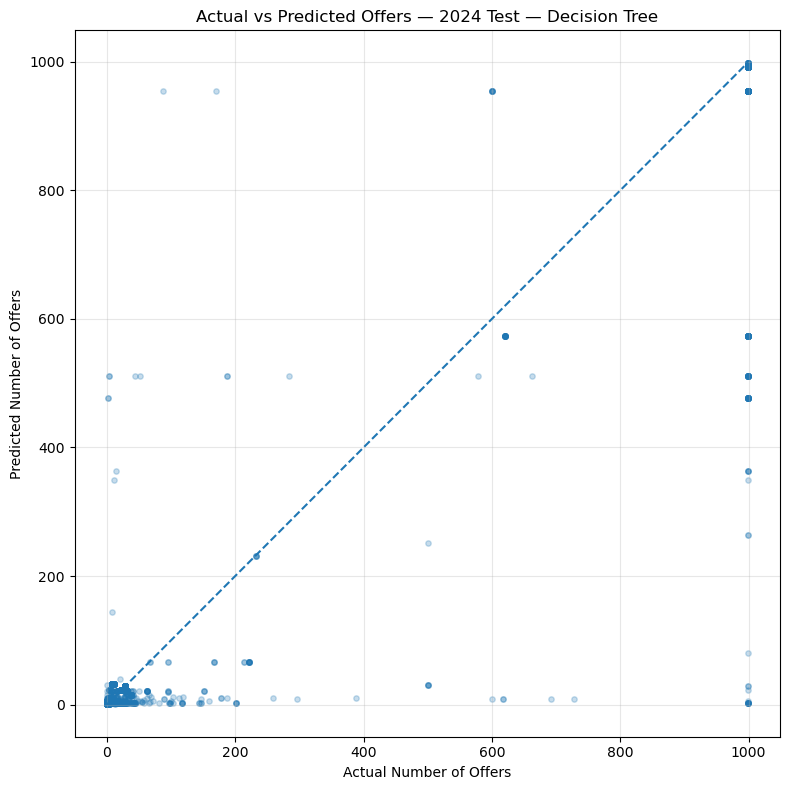

In [19]:
# Purpose: Visualize the computed Big Data statistics or model results for interpretation.
plt.figure(figsize=(8, 8))
plt.scatter(scatter_pd["actual"], scatter_pd["predicted"], alpha=0.25, s=15)
max_value = max(scatter_pd["actual"].max(),
    scatter_pd["predicted"].max()
)
plt.plot(
    [0, max_value],
    [0, max_value],
    linestyle="--"
)
plt.xlabel(
    "Actual Number of Offers"
)
plt.ylabel(
    "Predicted Number of Offers"
)
plt.title(
    f"Actual vs Predicted Offers — 2024 Test — "
    f"{best_model_name}"
)
plt.grid(
    alpha=0.3
)
plt.tight_layout()
plt.show()

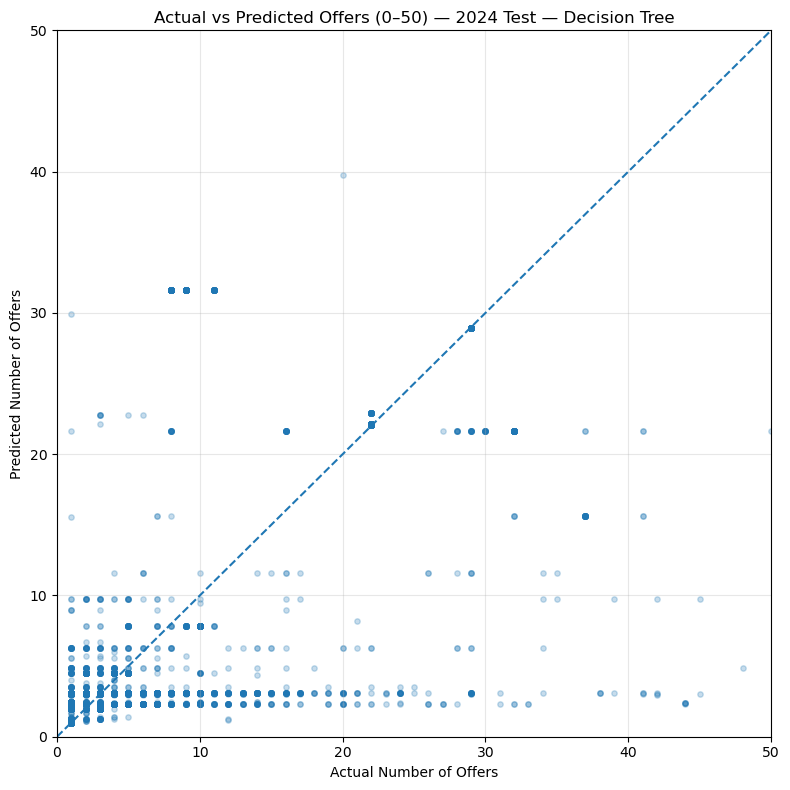

In [20]:
# Purpose: Visualize the computed Big Data statistics or model results for interpretation.
scatter_zoom = (scatter_pd[(scatter_pd["actual"] <= 50) & (scatter_pd["predicted"] <= 50)])
plt.figure(figsize=(8, 8))
plt.scatter(
    scatter_zoom["actual"],
    scatter_zoom["predicted"],
    alpha=0.25,
    s=15
)
plt.plot(
    [0, 50],
    [0, 50],
    linestyle="--"
)
plt.xlim(
    0,
    50
)
plt.ylim(
    0,
    50
)
plt.xlabel(
    "Actual Number of Offers"
)
plt.ylabel(
    "Predicted Number of Offers"
)
plt.title(
    f"Actual vs Predicted Offers (0–50) — "
    f"2024 Test — {best_model_name}"
)
plt.grid(
    alpha=0.3
)
plt.tight_layout()
plt.show()

## 15. Prediction error distribution — 2024 test

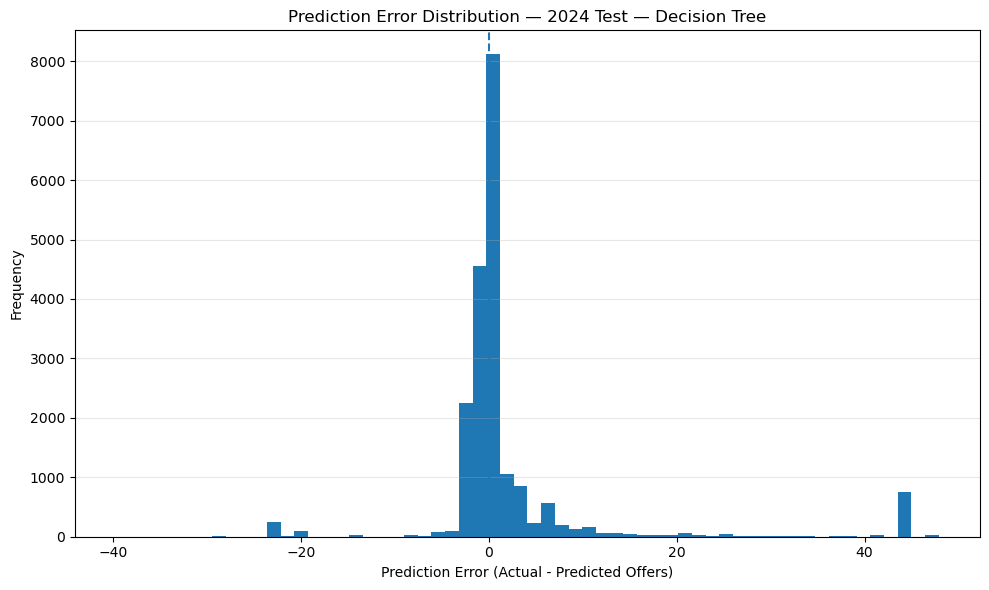

In [21]:
# Purpose: Visualize the computed Big Data statistics or model results for interpretation.
error_pd = (final_test_predictions.select((F.col("offers_label") - F.col("prediction_original")).alias("error"))
    .filter(
        F.abs(
            F.col("error")
        ) <= 50
    )
    .sample(
        False,
        0.02,
        seed=42
    )
    .limit(20000)
    .toPandas()
)
plt.figure(
    figsize=(10, 6)
)
plt.hist(
    error_pd["error"],
    bins=60
)
plt.axvline(
    0,
    linestyle="--"
)
plt.xlabel(
    "Prediction Error (Actual - Predicted Offers)"
)
plt.ylabel(
    "Frequency"
)
plt.title(
    f"Prediction Error Distribution — "
    f"2024 Test — {best_model_name}"
)
plt.grid(
    axis="y",
    alpha=0.3
)
plt.tight_layout()
plt.show()

# 16. Reconstruct the actual feature names

The saved `features` vector only contains:

```text
{'ml_attr': {'num_attrs': 1480}}
```

so using `offers_test_f.schema["features"].metadata` alone cannot recover names.

Instead, this section applies the **saved fitted preprocessing PipelineModel** to the raw ML schema and reads metadata from the intermediate `features_raw` column created by `VectorAssembler`. Standard scaling changes the values but **does not change the order or number of features**, so these names align exactly with the models' `features` vector.

In [22]:
# Purpose: Prepare `CATEGORICAL_FEATURES` for the next Big Data processing, analysis, or modeling step.
CATEGORICAL_FEATURES = ["award_type", "extent_competed", "solicitation_procedures", "type_of_set_aside",
    "awarding_agency_code", "awarding_subagency_code", "funding_agency_name", "naics2", "psc2",
    "recipient_state",
    "recipient_country",
    "pop_state",
    "pop_country"
]
NUMERIC_FEATURES = [
    "fiscal_year",
    "action_year",
    "action_month",
    "action_quarter",
    "duration_days",
    "has_parent_award",
    "small_business_flag_i"
]
encoded_columns = [
    f"{c}_ohe"
    for c in CATEGORICAL_FEATURES
]
imputed_columns = [
    f"{c}_imp"
    for c in NUMERIC_FEATURES
]
FEATURE_DISPLAY_NAMES = {
    "award_type":
        "Award Type",
    "extent_competed":
        "Extent Competed",
    "solicitation_procedures":
        "Solicitation Procedure",
    "type_of_set_aside":
        "Type of Set-Aside",
    "awarding_agency_code":
        "Awarding Agency Code",
    "awarding_subagency_code":
        "Awarding Subagency Code",
    "funding_agency_name":
        "Funding Agency",
    "naics2":
        "NAICS Sector",
    "psc2":
        "PSC Group",
    "recipient_state":
        "Recipient State",
    "recipient_country":
        "Recipient Country",
    "pop_state":
        "Place of Performance State",
    "pop_country":
        "Place of Performance Country",
    "fiscal_year":
        "Fiscal Year",
    "action_year":
        "Action Year",
    "action_month":
        "Action Month",
    "action_quarter":
        "Action Quarter",
    "duration_days":
        "Contract Duration (Days)",
    "has_parent_award":
        "Has Parent Award",
    "small_business_flag_i":
        "Small Business Flag"
}

In [23]:
# Purpose: Load the required Parquet data into `raw_feature_schema` for this Big Data processing stage.
raw_feature_schema = (spark.read.parquet(RAW_ML_PATH).limit(1))
preprocessed_schema = (offers_feature_model.transform(
        raw_feature_schema
    )
)
features_raw_metadata = (
    preprocessed_schema
    .schema["features_raw"]
    .metadata
)
features_raw_metadata

{'ml_attr': {'attrs': {'numeric': [{'idx': 1473, 'name': 'fiscal_year_imp'},
    {'idx': 1474, 'name': 'action_year_imp'},
    {'idx': 1475, 'name': 'action_month_imp'},
    {'idx': 1476, 'name': 'action_quarter_imp'},
    {'idx': 1477, 'name': 'duration_days_imp'},
    {'idx': 1478, 'name': 'has_parent_award_imp'},
    {'idx': 1479, 'name': 'small_business_flag_i_imp'}],
   'binary': [{'idx': 0, 'name': 'award_type_ohe___UNKNOWN__'},
    {'idx': 1, 'name': 'award_type_ohe_IDC'},
    {'idx': 2, 'name': 'award_type_ohe_BPA'},
    {'idx': 3, 'name': 'award_type_ohe_FSS'},
    {'idx': 4, 'name': 'award_type_ohe_B'},
    {'idx': 5, 'name': 'award_type_ohe_C'},
    {'idx': 6, 'name': 'award_type_ohe_A'},
    {'idx': 7, 'name': 'award_type_ohe_BOA'},
    {'idx': 8, 'name': 'award_type_ohe_D'},
    {'idx': 9, 'name': 'award_type_ohe_GWAC'},
    {'idx': 10, 'name': 'award_type_ohe___unknown'},
    {'idx': 11, 'name': 'extent_competed_ohe_COMPETED UNDER SAP'},
    {'idx': 12, 'name': 'extent_co

In [24]:
# Purpose: Define `extract_vector_attribute_names` to encapsulate the `extract_vector_attribute_names` processing logic for reuse.
def extract_vector_attribute_names(metadata):
    ml_attr = (metadata.get("ml_attr", {}))
    attrs = (
        ml_attr
        .get(
            "attrs",
            {}
        )
    )
    index_to_name = {}
    for attr_group in attrs.values():
        for item in attr_group:
            index_to_name[
                int(
                    item["idx"]
                )
            ] = (
                item["name"]
            )
    num_attrs = int(
        ml_attr.get(
            "num_attrs",
            len(
                index_to_name
            )
        )
    )
    return (
        index_to_name,
        num_attrs
    )
raw_feature_names, named_feature_count = (
    extract_vector_attribute_names(
        features_raw_metadata
    )
)
print(
    "Named features recovered:",
    len(
        raw_feature_names
    )
)
print(
    "Metadata feature count:",
    named_feature_count
)
print(
    "Model feature count:",
    test_feature_count
)
missing_feature_indices = [
    i
    for i in range(
        test_feature_count
    )
    if i not in raw_feature_names
]
assert (
    named_feature_count
    ==
    test_feature_count
), (
    "features_raw metadata dimension "
    "does not match the model dimension."
)
assert (
    len(
        missing_feature_indices
    )
    == 0
), (
    "Some feature names are still missing. "
    "The notebook intentionally stops instead "
    "of falling back to feature_123 names. "
    f"First missing indices: "
    f"{missing_feature_indices[:20]}"
)
print(
    "All feature indices have actual names."
)

Named features recovered: 1480
Metadata feature count: 1480
Model feature count: 1480
All feature indices have actual names.


## 17. Convert Spark pipeline names into readable feature/category labels

In [25]:
# Purpose: Define the helper functions used together in this Big Data processing step.
encoded_to_source = {f"{source}_ohe": source for source in CATEGORICAL_FEATURES}
imputed_to_source = {f"{source}_imp": source for source in
        NUMERIC_FEATURES
}
def clean_category_label(label):
    label = str(
        label
    )
    replacements = {
        "__UNKNOWN__":
            "Unknown",
        "invalidValues":
            "Unseen / Invalid",
        "__unknown":
            "Unknown"
    }
    return replacements.get(
        label,
        label
    )
def interpret_raw_feature_name(
    raw_name
):
    # Categorical one-hot feature:
    # e.g. award_type_ohe_A -> Award Type = A
    for encoded_col, source_col in (
        encoded_to_source.items()
    ):
        prefix = (
            encoded_col
            + "_"
        )
        if raw_name.startswith(
            prefix
        ):
            category = (
                raw_name[
                    len(prefix):
                ]
            )
            category = (
                clean_category_label(
                    category
                )
            )
            source_display = (
                FEATURE_DISPLAY_NAMES[
                    source_col
                ]
            )
            return (
                source_display,
                f"{source_display} = {category}"
            )
        if raw_name == encoded_col:
            source_display = (
                FEATURE_DISPLAY_NAMES[
                    source_col
                ]
            )
            return (
                source_display,
                source_display
            )
    # Numeric imputed feature:
    # e.g. duration_days_imp -> Contract Duration (Days)
    for imputed_col, source_col in (
        imputed_to_source.items()
    ):
        if raw_name == imputed_col:
            source_display = (
                FEATURE_DISPLAY_NAMES[
                    source_col
                ]
            )
            return (
                source_display,
                source_display
            )
    # Safety fallback for an unexpected pipeline-generated name.
    # This still preserves the real raw metadata name;
    # it never invents feature_123.
    readable = (
        raw_name
        .replace(
            "_",
            " "
        )
        .strip()
        .title()
    )
    return (
        readable,
        readable
    )

In [26]:
# Purpose: Map model feature indices to their original names and inspect feature importance.
feature_mapping_rows = []
for feature_index in range(test_feature_count):
    raw_name = (raw_feature_names[feature_index])
    (source_feature, display_feature
    ) = interpret_raw_feature_name(
        raw_name
    )
    feature_mapping_rows.append(
        {
            "feature_index":
                feature_index,
            "raw_feature_name":
                raw_name,
            "source_feature":
                source_feature,
            "display_feature":
                display_feature
        }
    )
feature_mapping_pd = (
    pd.DataFrame(
        feature_mapping_rows
    )
)
pd.set_option(
    "display.max_colwidth",
    120
)
feature_mapping_pd.head(
    50
)

,feature_index,raw_feature_name,source_feature,display_feature
0,0,award_type_ohe___UNKNOWN__,Award Type,Award Type = Unknown
1,1,award_type_ohe_IDC,Award Type,Award Type = IDC
2,2,award_type_ohe_BPA,Award Type,Award Type = BPA
3,3,award_type_ohe_FSS,Award Type,Award Type = FSS
4,4,award_type_ohe_B,Award Type,Award Type = B
5,5,award_type_ohe_C,Award Type,Award Type = C
6,6,award_type_ohe_A,Award Type,Award Type = A
7,7,award_type_ohe_BOA,Award Type,Award Type = BOA
8,8,award_type_ohe_D,Award Type,Award Type = D
9,9,award_type_ohe_GWAC,Award Type,Award Type = GWAC


In [27]:
# Purpose: Execute the code for the notebook section: 17. Convert Spark pipeline names into readable feature/category labels.
print("Feature mapping rows:", len(feature_mapping_pd))
print("Unique original/source features:", feature_mapping_pd["source_feature"
    ].nunique()
)
print(
    "Any generic feature_N names:",
    feature_mapping_pd[
        "display_feature"
    ]
    .str.match(
        r"^feature_\d+$",
        case=False
    )
    .any()
)

Feature mapping rows: 1480
Unique original/source features: 20
Any generic feature_N names: False


# 18. Feature-importance helpers

Two levels are shown:

- **Detailed level** — actual category/value, e.g. `NAICS Sector = 54`.
- **Original-feature level** — categories aggregated back to `NAICS Sector`, `Awarding Agency Code`, etc.

In [28]:
# Purpose: Define the helper functions used together in this Big Data processing step.
def tree_feature_importance_tables(model, feature_mapping):
    importance_vector = (model.featureImportances)
    assert (importance_vector.size == len(
            feature_mapping
        )
    )
    result = (
        feature_mapping
        .copy()
    )
    result[
        "importance"
    ] = [
        float(
            importance_vector[i]
        )
        for i in range(
            importance_vector.size
        )
    ]
    detailed = (
        result[
            result["importance"] > 0
        ]
        .sort_values(
            "importance",
            ascending=False
        )
        .reset_index(
            drop=True
        )
    )
    grouped = (
        result
        .groupby(
            "source_feature",
            as_index=False
        )[
            "importance"
        ]
        .sum()
        .sort_values(
            "importance",
            ascending=False
        )
        .reset_index(
            drop=True
        )
    )
    return (
        detailed,
        grouped
    )
def linear_regression_coefficient_tables(
    model,
    feature_mapping
):
    coefficients = (
        np.asarray(
            model.coefficients
        )
    )
    assert (
        len(
            coefficients
        )
        ==
        len(
            feature_mapping
        )
    )
    result = (
        feature_mapping
        .copy()
    )
    result[
        "coefficient"
    ] = coefficients
    result[
        "absolute_coefficient"
    ] = np.abs(
        coefficients
    )
    detailed = (
        result
        .sort_values(
            "absolute_coefficient",
            ascending=False
        )
        .reset_index(
            drop=True
        )
    )
    grouped = (
        result
        .groupby(
            "source_feature",
            as_index=False
        )[
            "absolute_coefficient"
        ]
        .sum()
        .sort_values(
            "absolute_coefficient",
            ascending=False
        )
        .reset_index(
            drop=True
        )
    )
    return (
        detailed,
        grouped
    )
def plot_horizontal_importance(
    dataframe,
    label_column,
    value_column,
    title,
    xlabel,
    top_n=20
):
    plot_df = (
        dataframe
        .head(
            top_n
        )
        .iloc[
            ::-1
        ]
    )
    plt.figure(
        figsize=(13, 8)
    )
    plt.barh(
        plot_df[
            label_column
        ],
        plot_df[
            value_column
        ]
    )
    plt.xlabel(
        xlabel
    )
    plt.ylabel(
        "Feature"
    )
    plt.title(
        title
    )
    plt.grid(
        axis="x",
        alpha=0.3
    )
    plt.tight_layout()
    plt.show()

## 19. Random Forest — actual feature names

In [29]:
# Purpose: Map model feature indices to their original names and inspect feature importance.
rf_detailed_pd, rf_grouped_pd = (tree_feature_importance_tables(trained_models["Random Forest"],
        feature_mapping_pd))
rf_detailed_pd[["feature_index",
        "display_feature",
        "importance"
    ]
].head(
    20
)

,feature_index,display_feature,importance
0,25,Solicitation Procedure = NEGOTIATED PROPOSAL/QUOTE,0.100362
1,137,Awarding Subagency Code = 4732,0.093464
2,318,Funding Agency = GENERAL SERVICES ADMINISTRATION,0.081569
3,63,Awarding Agency Code = 047,0.078625
4,12,Extent Competed = FULL AND OPEN COMPETITION,0.055611
5,23,Solicitation Procedure = SIMPLIFIED ACQUISITION,0.052763
6,1477,Contract Duration (Days),0.051436
7,1039,Place of Performance Country = Unknown,0.049961
8,445,PSC Group = 51,0.024370
9,426,NAICS Sector = 44,0.023259


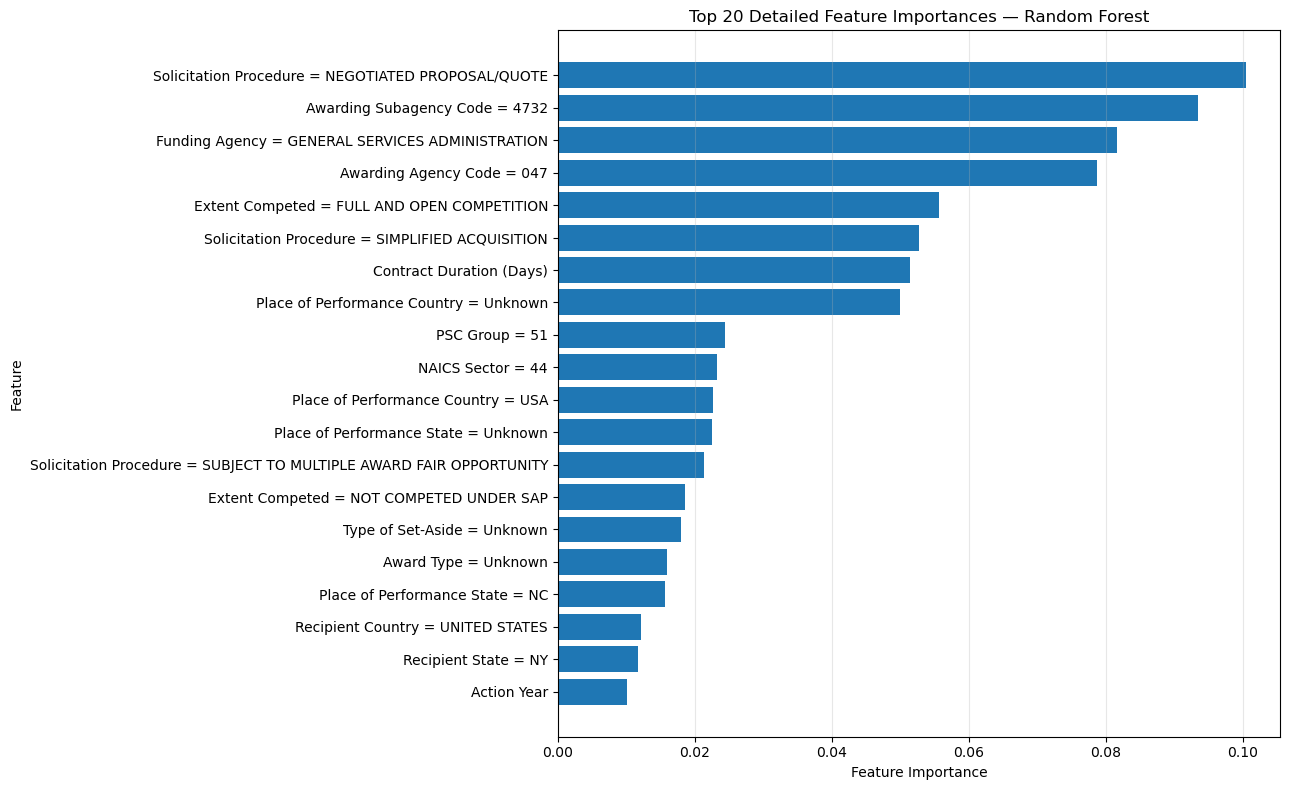

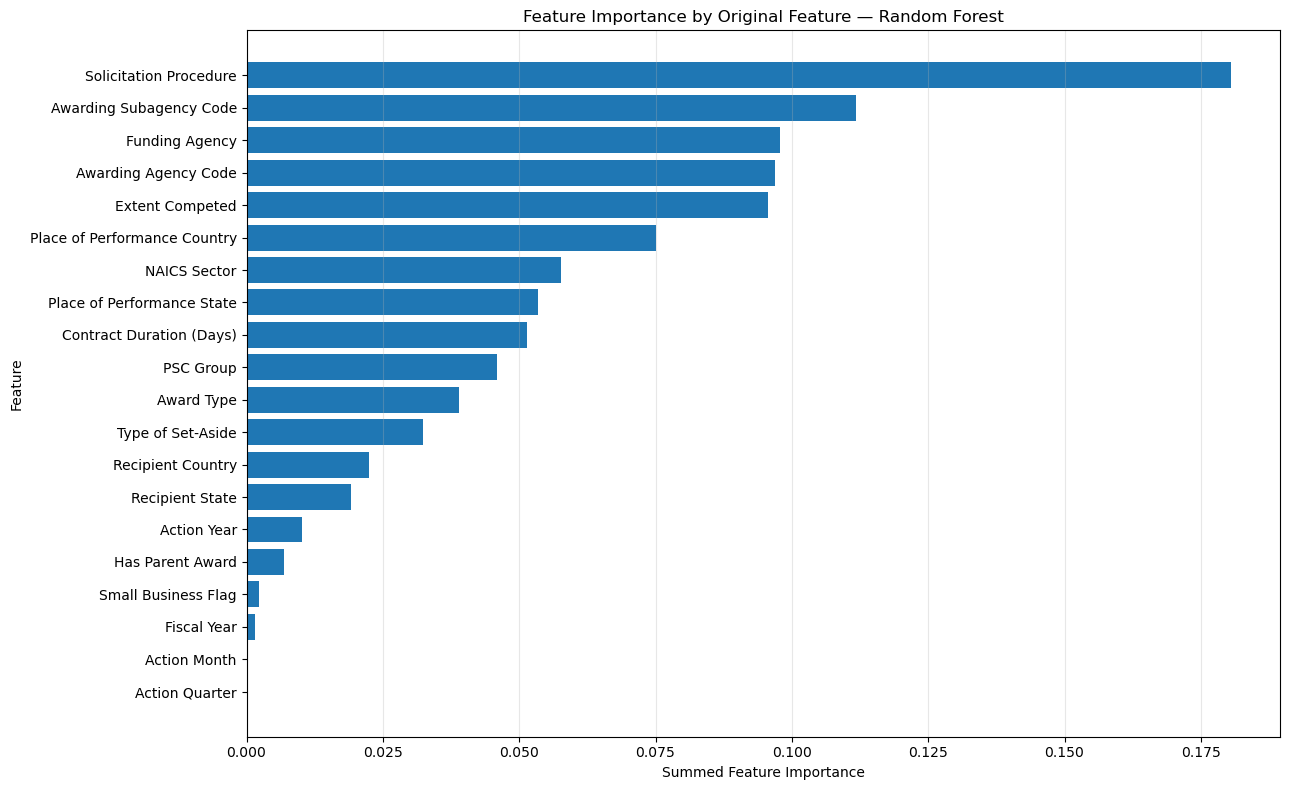

In [30]:
# Purpose: Execute the code for the notebook section: 19. Random Forest — actual feature names.
plot_horizontal_importance(rf_detailed_pd, "display_feature", "importance",
    "Top 20 Detailed Feature Importances — Random Forest", "Feature Importance", top_n=20)
plot_horizontal_importance(rf_grouped_pd, "source_feature",
    "importance",
    "Feature Importance by Original Feature — Random Forest",
    "Summed Feature Importance",
    top_n=20
)

## 20. GBT — actual feature names

In [31]:
# Purpose: Map model feature indices to their original names and inspect feature importance.
gbt_detailed_pd, gbt_grouped_pd = (tree_feature_importance_tables(trained_models["GBT"], feature_mapping_pd))
gbt_detailed_pd[[
        "feature_index",
        "display_feature",
        "importance"
    ]
].head(
    20
)

,feature_index,display_feature,importance
0,137,Awarding Subagency Code = 4732,0.128605
1,1039,Place of Performance Country = Unknown,0.124393
2,6,Award Type = A,0.085104
3,3,Award Type = FSS,0.081518
4,426,NAICS Sector = 44,0.037358
5,1477,Contract Duration (Days),0.028236
6,1474,Action Year,0.025715
7,429,NAICS Sector = 62,0.025179
8,454,PSC Group = F0,0.023441
9,1,Award Type = IDC,0.023111


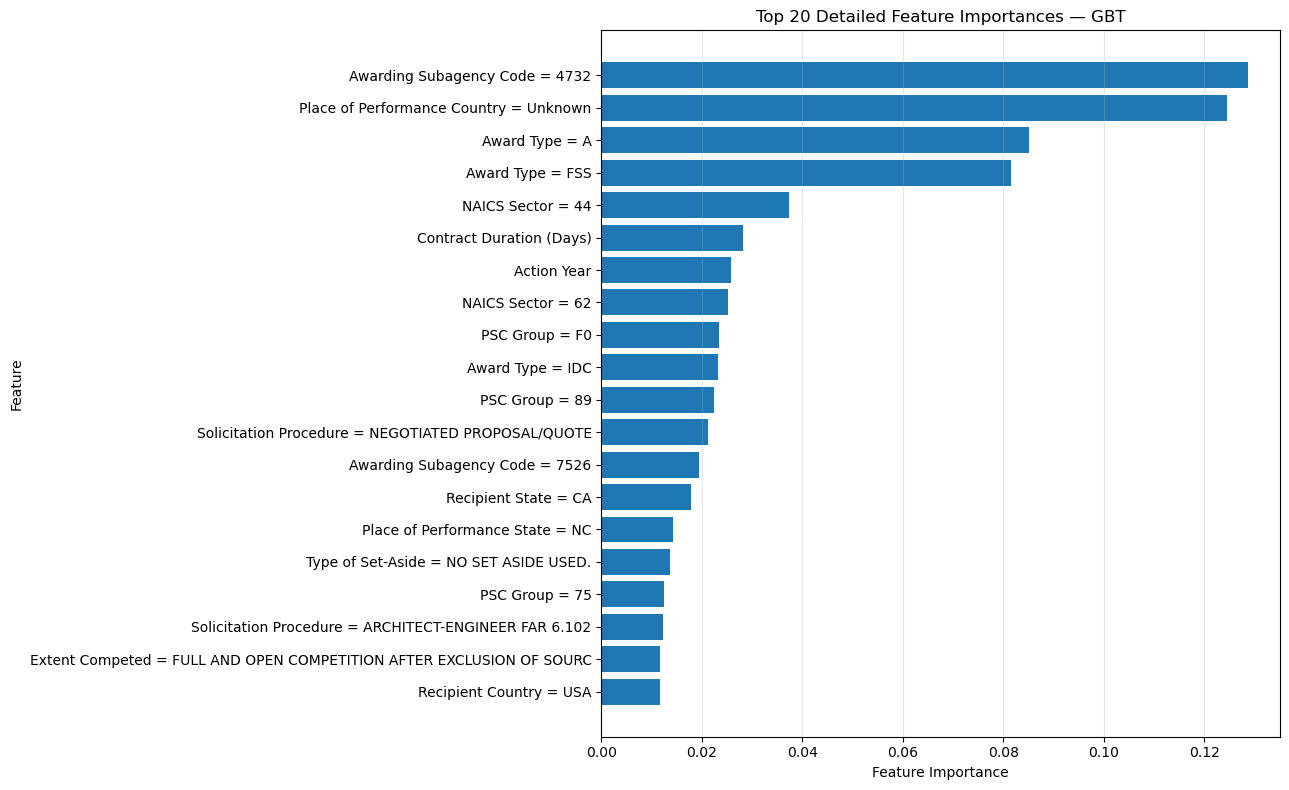

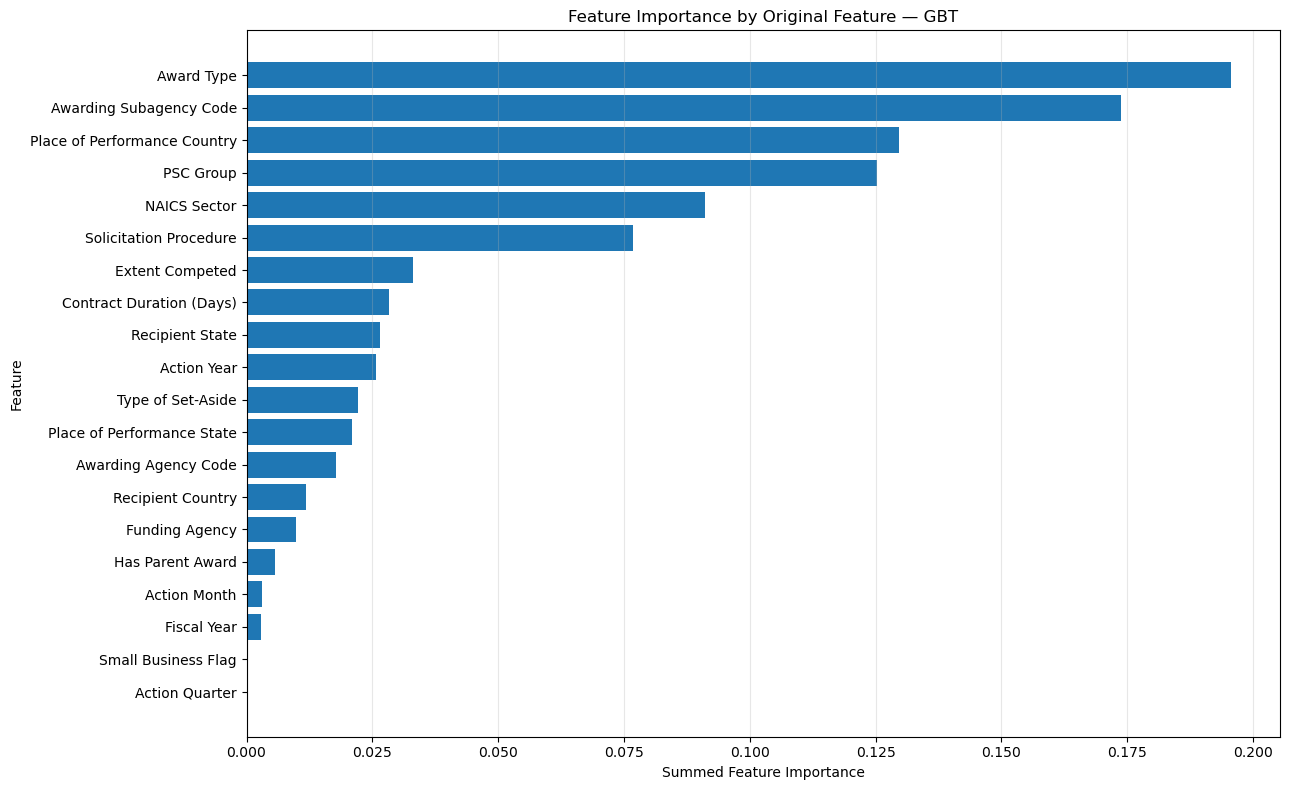

In [32]:
# Purpose: Execute the code for the notebook section: 20. GBT — actual feature names.
plot_horizontal_importance(gbt_detailed_pd, "display_feature", "importance",
    "Top 20 Detailed Feature Importances — GBT", "Feature Importance", top_n=20)
plot_horizontal_importance(gbt_grouped_pd, "source_feature",
    "importance",
    "Feature Importance by Original Feature — GBT",
    "Summed Feature Importance",
    top_n=20
)

## 21. Decision Tree — actual feature names

In [33]:
# Purpose: Map model feature indices to their original names and inspect feature importance.
dt_detailed_pd, dt_grouped_pd = (tree_feature_importance_tables(trained_models["Decision Tree"],
        feature_mapping_pd))
dt_detailed_pd[["feature_index",
        "display_feature",
        "importance"
    ]
].head(
    20
)

,feature_index,display_feature,importance
0,137,Awarding Subagency Code = 4732,0.269571
1,1039,Place of Performance Country = Unknown,0.247387
2,3,Award Type = FSS,0.164202
3,426,NAICS Sector = 44,0.079474
4,987,Place of Performance State = NC,0.030234
5,25,Solicitation Procedure = NEGOTIATED PROPOSAL/QUOTE,0.029523
6,34,Type of Set-Aside = NO SET ASIDE USED.,0.019911
7,13,Extent Competed = NOT COMPETED UNDER SAP,0.017841
8,26,Solicitation Procedure = ONLY ONE SOURCE,0.014554
9,446,PSC Group = 65,0.013104


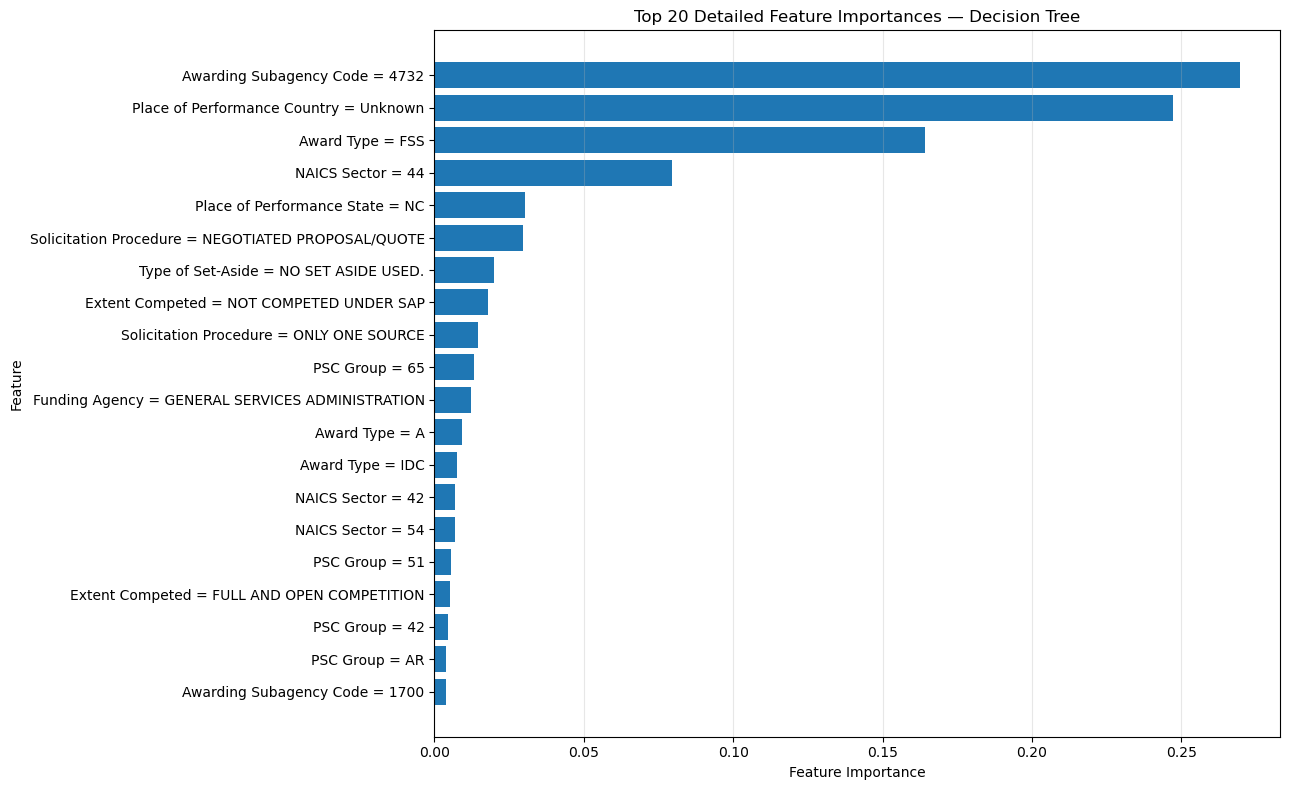

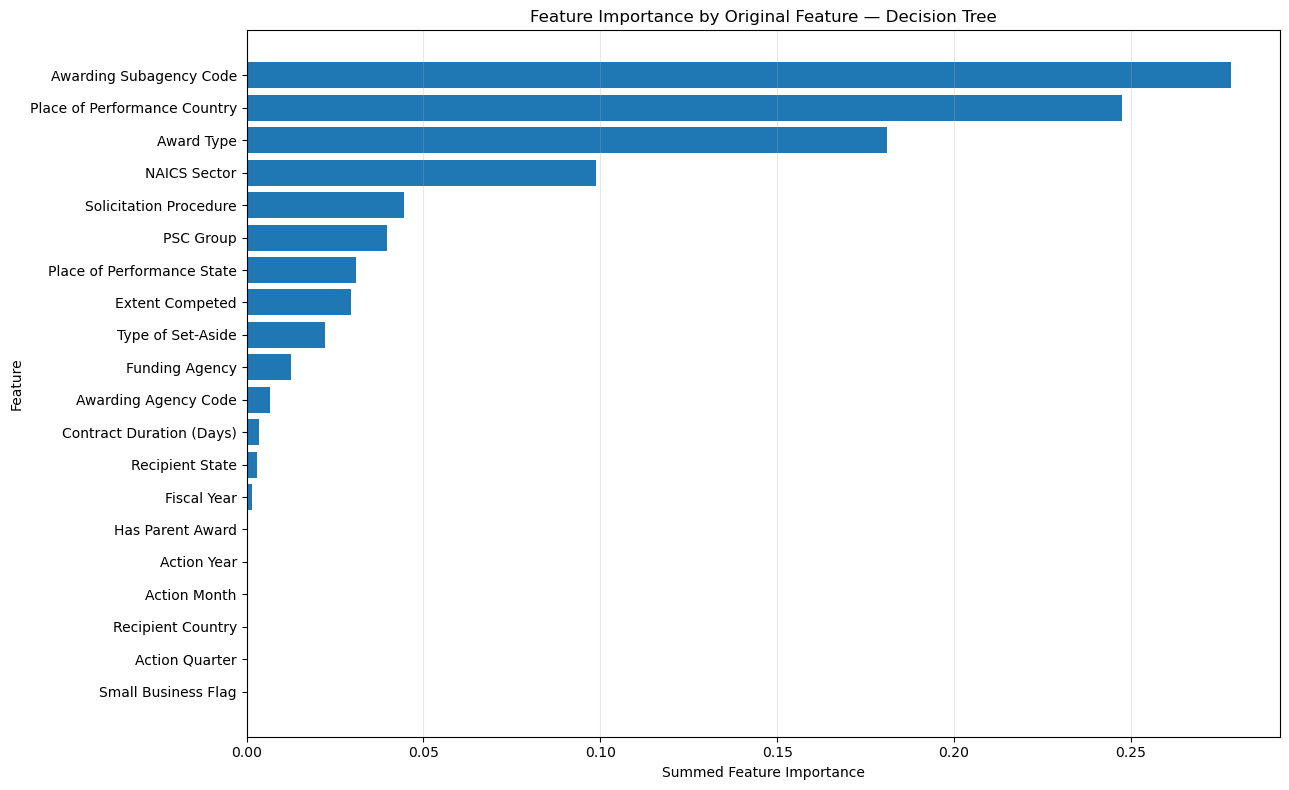

In [34]:
# Purpose: Execute the code for the notebook section: 21. Decision Tree — actual feature names.
plot_horizontal_importance(dt_detailed_pd, "display_feature", "importance",
    "Top 20 Detailed Feature Importances — Decision Tree", "Feature Importance", top_n=20)
plot_horizontal_importance(dt_grouped_pd, "source_feature",
    "importance",
    "Feature Importance by Original Feature — Decision Tree",
    "Summed Feature Importance",
    top_n=20
)

## 22. Linear Regression coefficients — actual feature names

Because the model was trained on **standardized features** and predicts `log1p(offers)`, the coefficient visual is best interpreted as relative signed association on the model's transformed scale, not as raw "offers added" per original unit.

In [35]:
# Purpose: Execute the code for the notebook section: 22. Linear Regression coefficients — actual feature names.
lr_detailed_pd, lr_grouped_pd = (linear_regression_coefficient_tables(trained_models["Linear Regression"],
        feature_mapping_pd))
lr_detailed_pd[["feature_index",
        "display_feature",
        "coefficient",
        "absolute_coefficient"
    ]
].head(
    20
)

,feature_index,display_feature,coefficient,absolute_coefficient
0,318,Funding Agency = GENERAL SERVICES ADMINISTRATION,0.287315,0.287315
1,25,Solicitation Procedure = NEGOTIATED PROPOSAL/QUOTE,0.226843,0.226843
2,1039,Place of Performance Country = Unknown,0.169352,0.169352
3,12,Extent Competed = FULL AND OPEN COMPETITION,0.167981,0.167981
4,13,Extent Competed = NOT COMPETED UNDER SAP,-0.166739,0.166739
5,137,Awarding Subagency Code = 4732,0.160836,0.160836
6,987,Place of Performance State = NC,0.146752,0.146752
7,1037,Place of Performance Country = USA,-0.145643,0.145643
8,622,Recipient State = NY,0.144497,0.144497
9,150,Awarding Subagency Code = 4740,-0.138327,0.138327


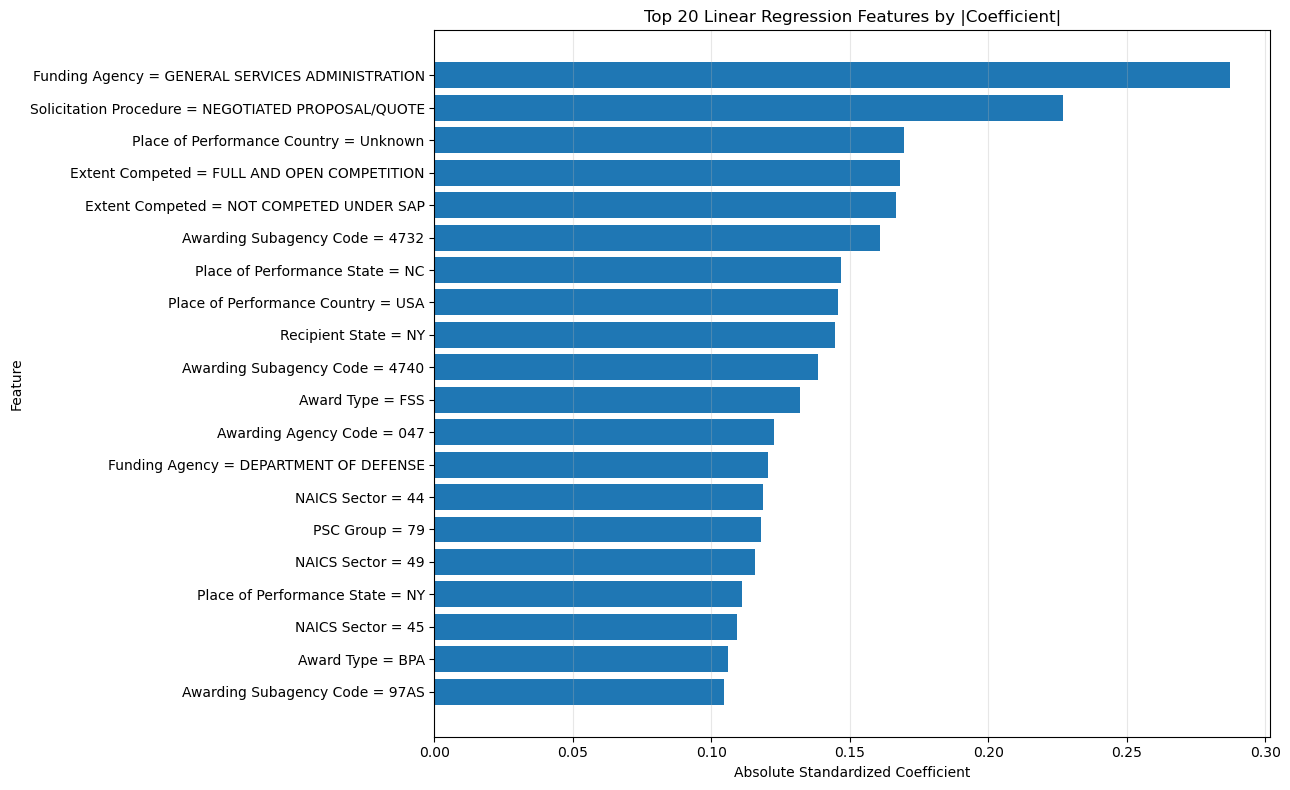

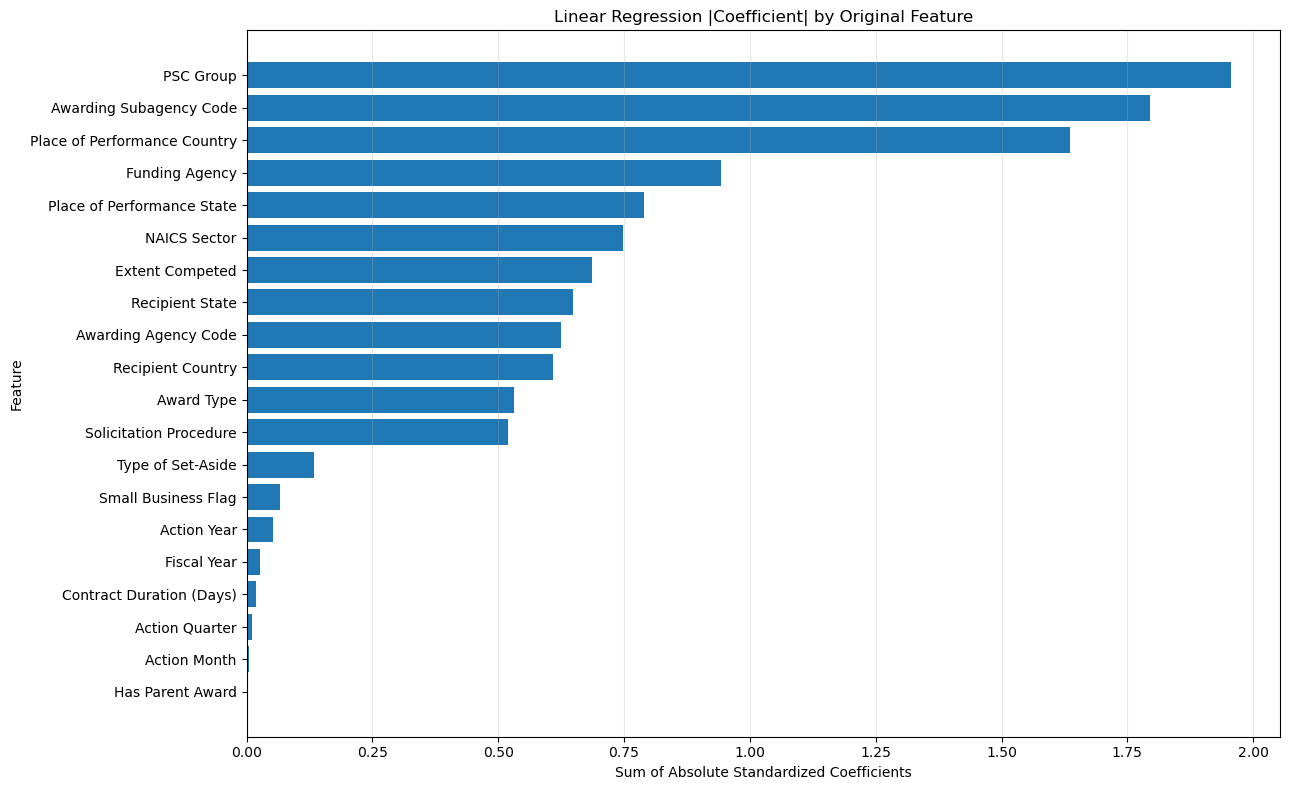

In [36]:
# Purpose: Execute the code for the notebook section: 22. Linear Regression coefficients — actual feature names.
plot_horizontal_importance(lr_detailed_pd, "display_feature", "absolute_coefficient",
    "Top 20 Linear Regression Features by |Coefficient|", "Absolute Standardized Coefficient", top_n=20)
plot_horizontal_importance(lr_grouped_pd, "source_feature",
    "absolute_coefficient",
    "Linear Regression |Coefficient| by Original Feature",
    "Sum of Absolute Standardized Coefficients",
    top_n=20
)

## 23. Optional: inspect the signed Linear Regression coefficients

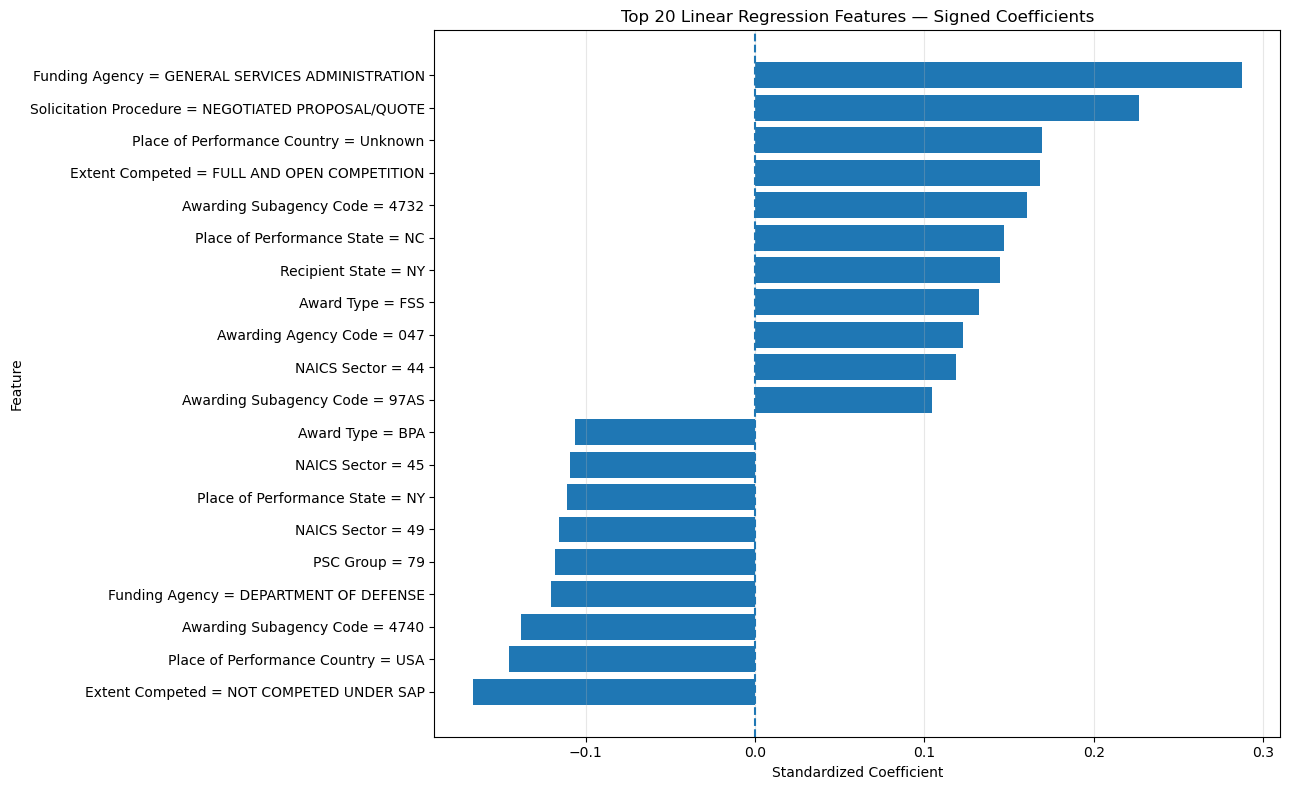

In [37]:
# Purpose: Visualize the computed Big Data statistics or model results for interpretation.
lr_signed_top20_pd = (lr_detailed_pd.head(20).sort_values("coefficient"))
plt.figure(figsize=(13, 8))
plt.barh(
    lr_signed_top20_pd[
        "display_feature"
    ],
    lr_signed_top20_pd[
        "coefficient"
    ]
)
plt.axvline(
    0,
    linestyle="--"
)
plt.xlabel(
    "Standardized Coefficient"
)
plt.ylabel(
    "Feature"
)
plt.title(
    "Top 20 Linear Regression Features — Signed Coefficients"
)
plt.grid(
    axis="x",
    alpha=0.3
)
plt.tight_layout()
plt.show()

## 24. Compact final evaluation table

In [38]:
# Purpose: Evaluate regression performance using the configured error and goodness-of-fit metrics.
final_evaluation_pd = (test_results_pd[["model", "mae", "rmse", "r2", "log_rmse",
            "exact_accuracy_pct", "within_1_pct",
            "within_2_pct",
            "within_5_pct"
        ]
    ]
    .copy()
)
for column in [
    "mae",
    "rmse",
    "r2",
    "log_rmse",
    "exact_accuracy_pct",
    "within_1_pct",
    "within_2_pct",
    "within_5_pct"
]:
    final_evaluation_pd[
        column
    ] = (
        final_evaluation_pd[
            column
        ]
        .round(4)
    )
final_evaluation_pd

,model,mae,rmse,r2,log_rmse,exact_accuracy_pct,within_1_pct,within_2_pct,within_5_pct
0,Decision Tree,10.6024,62.1229,0.9338,0.5949,37.5549,47.6190,67.7306,84.6665
1,GBT,15.0215,75.1334,0.9032,0.6087,26.9938,40.3849,62.4713,81.6769
2,Linear Regression,58.1634,206.3918,0.2693,1.0281,17.1091,30.1928,44.5451,62.8633
3,Random Forest,62.6744,231.6313,0.0796,1.0054,7.4391,19.1361,51.4458,78.9447


## 25. Optional save cells

These are commented out deliberately so running the notebook does not overwrite anything unless you choose to save the new test outputs.

In [39]:
# Purpose: Write the processed Big Data or trained model artifact to the configured GCS location.
# TEST_RESULTS_OUTPUT = (
#     "gs://federal-contracts/"
#     "models/offers/test_metrics_all_models"
# )
#
# test_results_spark = (
#     spark.createDataFrame(
#         test_results_pd
#     )
# )
#
# (
#     test_results_spark
#     .write
#     .mode("overwrite")
#     .parquet(
#         TEST_RESULTS_OUTPUT
#     )
# )
#
# print(
#     "Saved:",
#     TEST_RESULTS_OUTPUT
# )

## 26. Cleanup

In [40]:
# Purpose: Execute the code for the notebook section: 26. Cleanup.
final_test_predictions.unpersist()
offers_test_f.unpersist()
print("Released cached test DataFrames.")

Released cached test DataFrames.
